The dataset was be installed from the website: https://networkrepository.com/index.php

The small nodes dataset can be found at: https://networkrepository.com/ia-primary-school-proximity-attr.php

The large nodes dataset can be found at: https://networkrepository.com/fb-pages-sport.php

Small Network Statistics:
Number of nodes: 242
Number of edges: 8317
Number of self loops: 0
Number of isolated nodes: 0


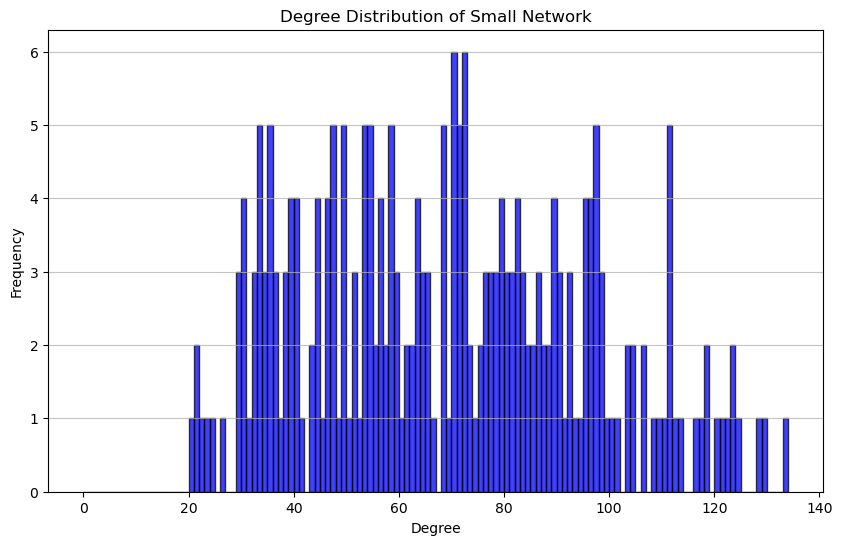

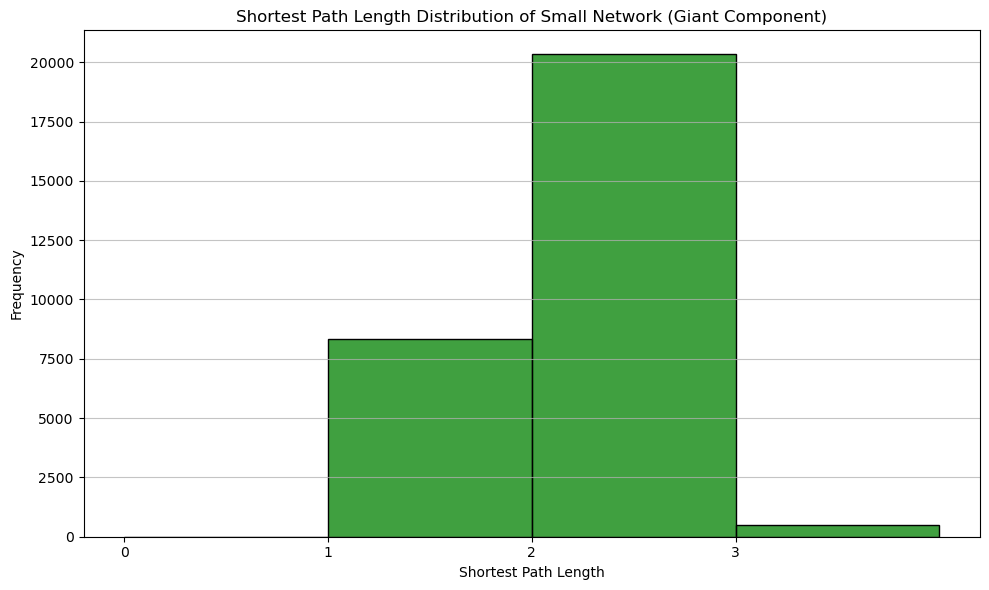

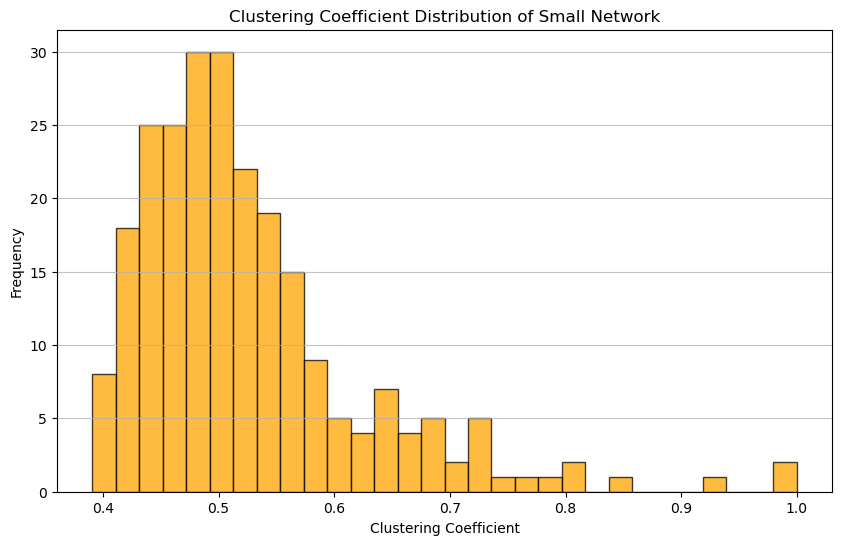


 Part (a) Averages
Average Degree: 68.7355
Average Shortest Path Length (Giant Component): 1.7325
Average Clustering Coefficient: 0.5255


In [19]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir('D:/HKUST/5056_Network_Modeling/Project/Project')

# Load small network
small_data_path = 'ia-primary-school-proximity-attr.edges'
df_small = pd.read_csv(small_data_path, sep=',', usecols=[0, 1], header=None, dtype=str)

G_small = nx.Graph()
edges_small = df_small.to_numpy()
G_small.add_edges_from(edges_small)

# Basic statistics
print("Small Network Statistics:")
print(f"Number of nodes: {G_small.number_of_nodes()}")
print(f"Number of edges: {G_small.number_of_edges()}")
print(f"Number of self loops: {len(list(nx.selfloop_edges(G_small)))}")
print(f"Number of isolated nodes: {len(list(nx.isolates(G_small)))}")

## Part (a)

# (a1) Degree distribution
small_degrees = [degree for node, degree in G_small.degree()]
plt.figure(figsize=(10, 6))
plt.hist(small_degrees, bins=range(max(small_degrees) + 1), alpha=0.75, color='blue', edgecolor='black')
plt.title('Degree Distribution of Small Network')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# (a2) Shortest path length distribution (computed only on the giant component)
largest_cc = max(nx.connected_components(G_small), key=len)
G_giant = G_small.subgraph(largest_cc).copy()

nodes_list = list(G_giant.nodes())
all_distances = []
for i in range(len(nodes_list)):
    for j in range(i + 1, len(nodes_list)):
        source, target = nodes_list[i], nodes_list[j]
        path_length = nx.shortest_path_length(G_giant, source, target)
        all_distances.append(path_length)

plt.figure(figsize=(10, 6))
sns.histplot(all_distances, bins=range(max(all_distances) + 2), color='green', edgecolor='black', alpha=0.75, kde=False)
plt.title('Shortest Path Length Distribution of Small Network (Giant Component)')
plt.xlabel('Shortest Path Length')
plt.ylabel('Frequency')
plt.xticks(range(max(all_distances) + 1))
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# (a3) Clustering coefficient distribution
small_clustering_coeffs = list(nx.clustering(G_small).values())
plt.figure(figsize=(10, 6))
plt.hist(small_clustering_coeffs, bins=30, alpha=0.75, color='orange', edgecolor='black')
plt.title('Clustering Coefficient Distribution of Small Network')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Compute averages
avg_small_degree = sum(small_degrees) / len(small_degrees)
avg_small_distance = sum(all_distances) / len(all_distances)
avg_small_clustering = sum(small_clustering_coeffs) / len(small_clustering_coeffs)

print(f"\n Part (a) Averages")
print(f"Average Degree: {avg_small_degree:.4f}")
print(f"Average Shortest Path Length (Giant Component): {avg_small_distance:.4f}")
print(f"Average Clustering Coefficient: {avg_small_clustering:.4f}")

Best partition: 9 communities, Modularity = 0.0002


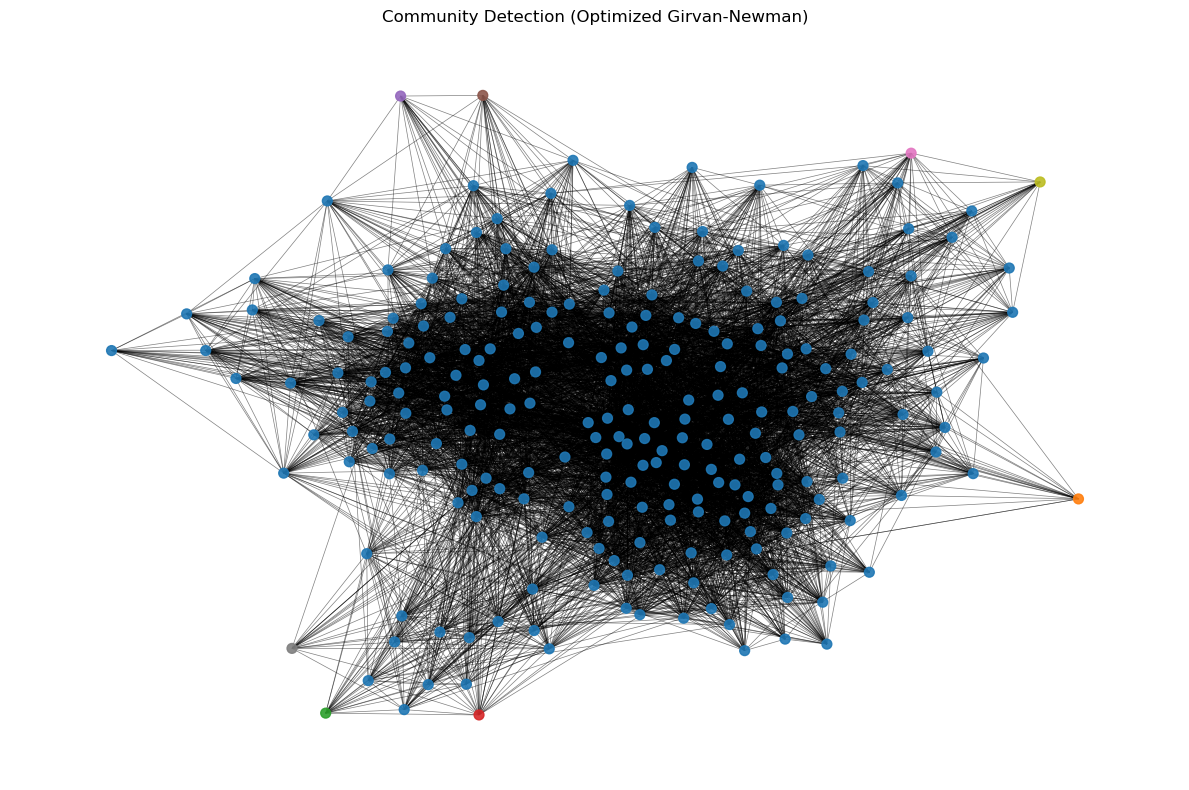

In [25]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# (b)(i) Optimized Girvan-Newman for small network
# Optimization: use approximate edge betweenness with k=50 sample nodes
# and stop after max 20 communities (to avoid O(n^4) explosion)

def girvan_newman_with_k(graph, k=None, max_communities=10):
    """
    Approximate Girvan-Newman using sampled betweenness.
    k: number of random nodes to use for betweenness estimation (None = exact)
    max_communities: stop early to save time
    """
    g = graph.copy()
    components = [set(g.nodes())]  # initial single community
    partitions = [components]

    while len(components) < max_communities and g.number_of_edges() > 0:
        # Compute approximate edge betweenness
        if k is None or k >= g.number_of_nodes():
            betweenness = nx.edge_betweenness_centrality(g)
        else:
            # Use only k random nodes to estimate betweenness
            nodes_sample = np.random.choice(list(g.nodes()), size=min(k, g.number_of_nodes()), replace=False)
            betweenness = nx.edge_betweenness_centrality(g, k=len(nodes_sample), normalized=False)
        
        # Remove edge with highest betweenness
        edge_to_remove = max(betweenness, key=betweenness.get)
        g.remove_edge(*edge_to_remove)
        
        # Get new components
        components = list(nx.connected_components(g))
        partitions.append(components)
    
    return partitions

# Run optimized GN
partitions = girvan_newman_with_k(G_small, k=50, max_communities=10)

# Compute modularity for each partition
modularities = []
community_partitions = []
for comm in partitions:
    comm_list = [list(c) for c in comm]
    community_partitions.append(comm_list)
    mod = nx.community.modularity(G_small, comm_list)
    modularities.append(mod)

# Find best partition
best_idx = int(np.argmax(modularities))
best_communities = community_partitions[best_idx]
print(f"Best partition: {len(best_communities)} communities, Modularity = {modularities[best_idx]:.4f}")

# Visualization (same as before)
color_map = []
for node in G_small.nodes():
    for i, comm in enumerate(best_communities):
        if node in comm:
            color_map.append(plt.cm.tab10(i % 10))
            break

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_small, seed=3042, k=0.15)
nx.draw_networkx_nodes(G_small, pos, node_color=color_map, node_size=50, alpha=0.9)
nx.draw_networkx_edges(G_small, pos, width=0.5, alpha=0.5)
plt.title('Community Detection (Optimized Girvan-Newman)')
plt.axis('off')
plt.tight_layout()
plt.show()


Large Network Statistics:
Number of nodes: 13866
Number of edges: 86858
Number of self loops: 47
Number of isolated nodes: 0

Giant Component Statistics:
Number of nodes in Giant Component: 13866
Percentage of total nodes: 100.00%


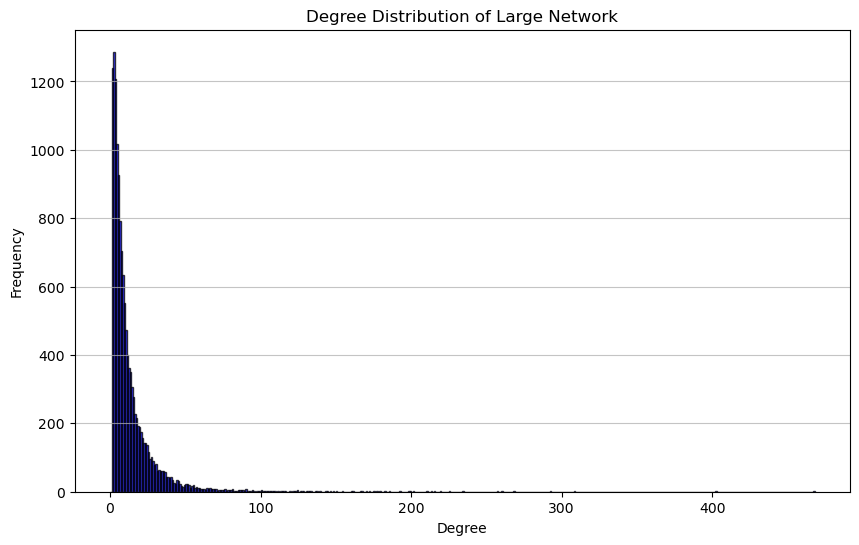

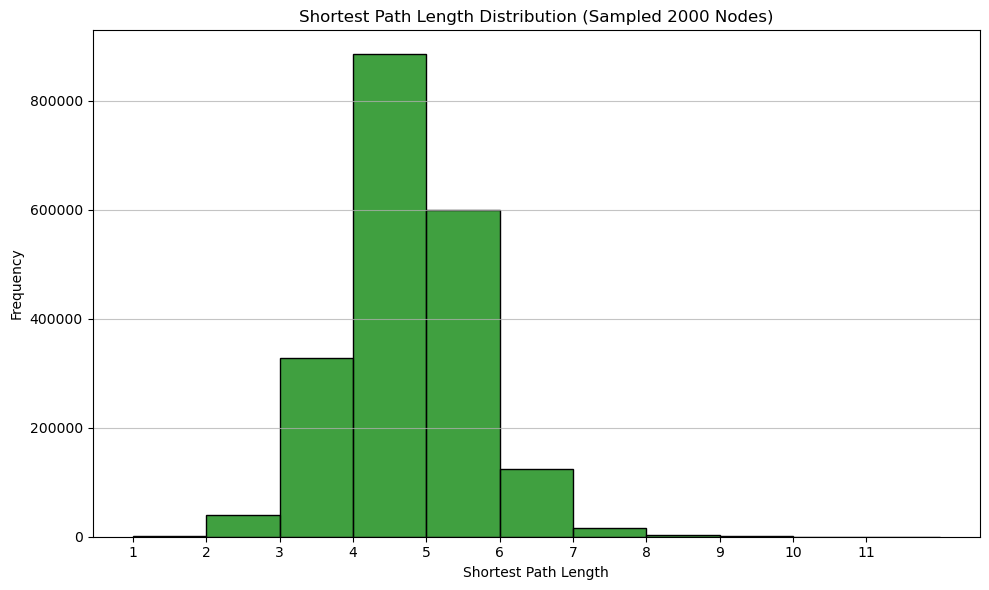

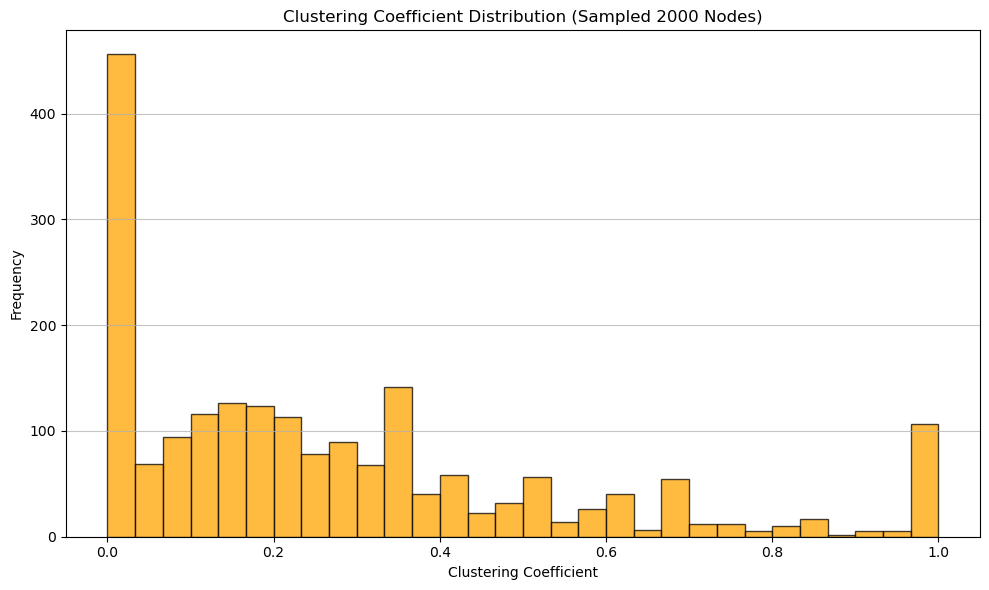


 Averages for Large Network
Average Degree: 12.5282
Average Shortest Path Length (Sampled): 4.2510
Average Clustering Coefficient (Sampled): 0.2724

Top 10 highest degree nodes (with page names):
Node 6221 (NBA): Degree = 468
Node 5328 (UFC): Degree = 402
Node 3108 (Cristiano Ronaldo): Degree = 308
Node 11976 (NFL): Degree = 292
Node 11134 (LeBron James): Degree = 268
Node 3334 (UEFA Champions League): Degree = 260
Node 11881 (John Doomsday Howard MMA): Degree = 257
Node 8137 (Leo Messi): Degree = 234
Node 13571 (Martyn Ashton): Degree = 225
Node 12449 (Team USA): Degree = 219


In [34]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random

os.chdir('D:/HKUST/5056_Network_Modeling/Project/Project')

random.seed(3042)
# large network (Facebook Sports Pages)
nodes_path = 'fb-pages-sport.nodes'
nodes_df = pd.read_csv(nodes_path, header=None, names=['id', 'name', 'new_id'], dtype=str)

# Load edges file (contains connections between new_id)
edges_path = 'fb-pages-sport.edges'
df_large = pd.read_csv(edges_path, sep=',', usecols=[0, 1], header=None, dtype=str)

G_large = nx.Graph()
edges_large = df_large.to_numpy()
G_large.add_edges_from(edges_large)

# Add node attributes (page names) to the graph
# Create a mapping from new_id to page name
node_names = dict(zip(nodes_df['new_id'], nodes_df['name']))
for node in G_large.nodes():
    if node in node_names:
        G_large.nodes[node]['name'] = node_names[node]

# Basic statistics
print("\nLarge Network Statistics:")
print(f"Number of nodes: {G_large.number_of_nodes()}")
print(f"Number of edges: {G_large.number_of_edges()}")
print(f"Number of self loops: {len(list(nx.selfloop_edges(G_large)))}")
print(f"Number of isolated nodes: {len(list(nx.isolates(G_large)))}")

# Giant component info
largest_cc = max(nx.connected_components(G_large), key=len)
G_giant = G_large.subgraph(largest_cc).copy()
print(f"\nGiant Component Statistics:")
print(f"Number of nodes in Giant Component: {G_giant.number_of_nodes()}")
print(f"Percentage of total nodes: {G_giant.number_of_nodes()/G_large.number_of_nodes():.2%}")

## Part (a)

# (a1) Degree distribution 
large_degrees = [degree for _, degree in G_large.degree()]
plt.figure(figsize=(10, 6))
plt.hist(large_degrees, bins=range(max(large_degrees) + 1), alpha=0.75, color='blue', edgecolor='black')
plt.title('Degree Distribution of Large Network')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# (a2) Shortest path length distribution - We'll sample a representative subset of nodes
sample_size = 2000
sample_nodes = random.sample(list(G_giant.nodes()), min(sample_size, G_giant.number_of_nodes()))

all_distances = []
for i, source in enumerate(sample_nodes):    
    # Get shortest paths from source to all other sampled nodes
    lengths = nx.single_source_shortest_path_length(G_giant, source)
    for target in sample_nodes[i+1:]:
        if target in lengths:  # Ensure target is reachable
            all_distances.append(lengths[target])

plt.figure(figsize=(10, 6))
max_dist = max(all_distances) if all_distances else 10
sns.histplot(all_distances, bins=range(1, max_dist + 2), color='green', 
             edgecolor='black', alpha=0.75, kde=False)
plt.title(f'Shortest Path Length Distribution (Sampled {len(sample_nodes)} Nodes)')
plt.xlabel('Shortest Path Length')
plt.ylabel('Frequency')
plt.xticks(range(1, max_dist + 1))
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# (a3) Clustering coefficient distribution - optimized with sampling
sample_nodes_clustering = random.sample(list(G_large.nodes()), min(2000, G_large.number_of_nodes()))
large_clustering_coeffs = [nx.clustering(G_large, node) for node in sample_nodes_clustering]

plt.figure(figsize=(10, 6))
plt.hist(large_clustering_coeffs, bins=30, alpha=0.75, color='orange', edgecolor='black')
plt.title(f'Clustering Coefficient Distribution (Sampled {len(sample_nodes_clustering)} Nodes)')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Compute averages using sampled data for large network
avg_large_degree = sum(large_degrees) / len(large_degrees)
avg_shortest_path_length = sum(all_distances) / len(all_distances) if all_distances else 0
avg_large_clustering = sum(large_clustering_coeffs) / len(large_clustering_coeffs)

print(f"\n Averages for Large Network")
print(f"Average Degree: {avg_large_degree:.4f}")
print(f"Average Shortest Path Length (Sampled): {avg_shortest_path_length:.4f}")
print(f"Average Clustering Coefficient (Sampled): {avg_large_clustering:.4f}")

# Print some example high-degree nodes with their names
print("\nTop 10 highest degree nodes (with page names):")
degree_dict = dict(G_large.degree())
sorted_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
for node_id, degree in sorted_nodes:
    page_name = G_large.nodes[node_id].get('name', 'Unknown')
    print(f"Node {node_id} ({page_name}): Degree = {degree}")


Louvain Community Detection Results:
Number of communities found: 26

Top 10 largest communities:
Community 1: 2146 nodes
Community 5: 2141 nodes
Community 8: 1297 nodes
Community 9: 1138 nodes
Community 15: 1006 nodes
Community 10: 930 nodes
Community 2: 855 nodes
Community 14: 681 nodes
Community 0: 484 nodes
Community 7: 468 nodes
Modularity: 0.7145

Community Graph Statistics:
Number of community nodes: 26
Number of edges between communities: 210


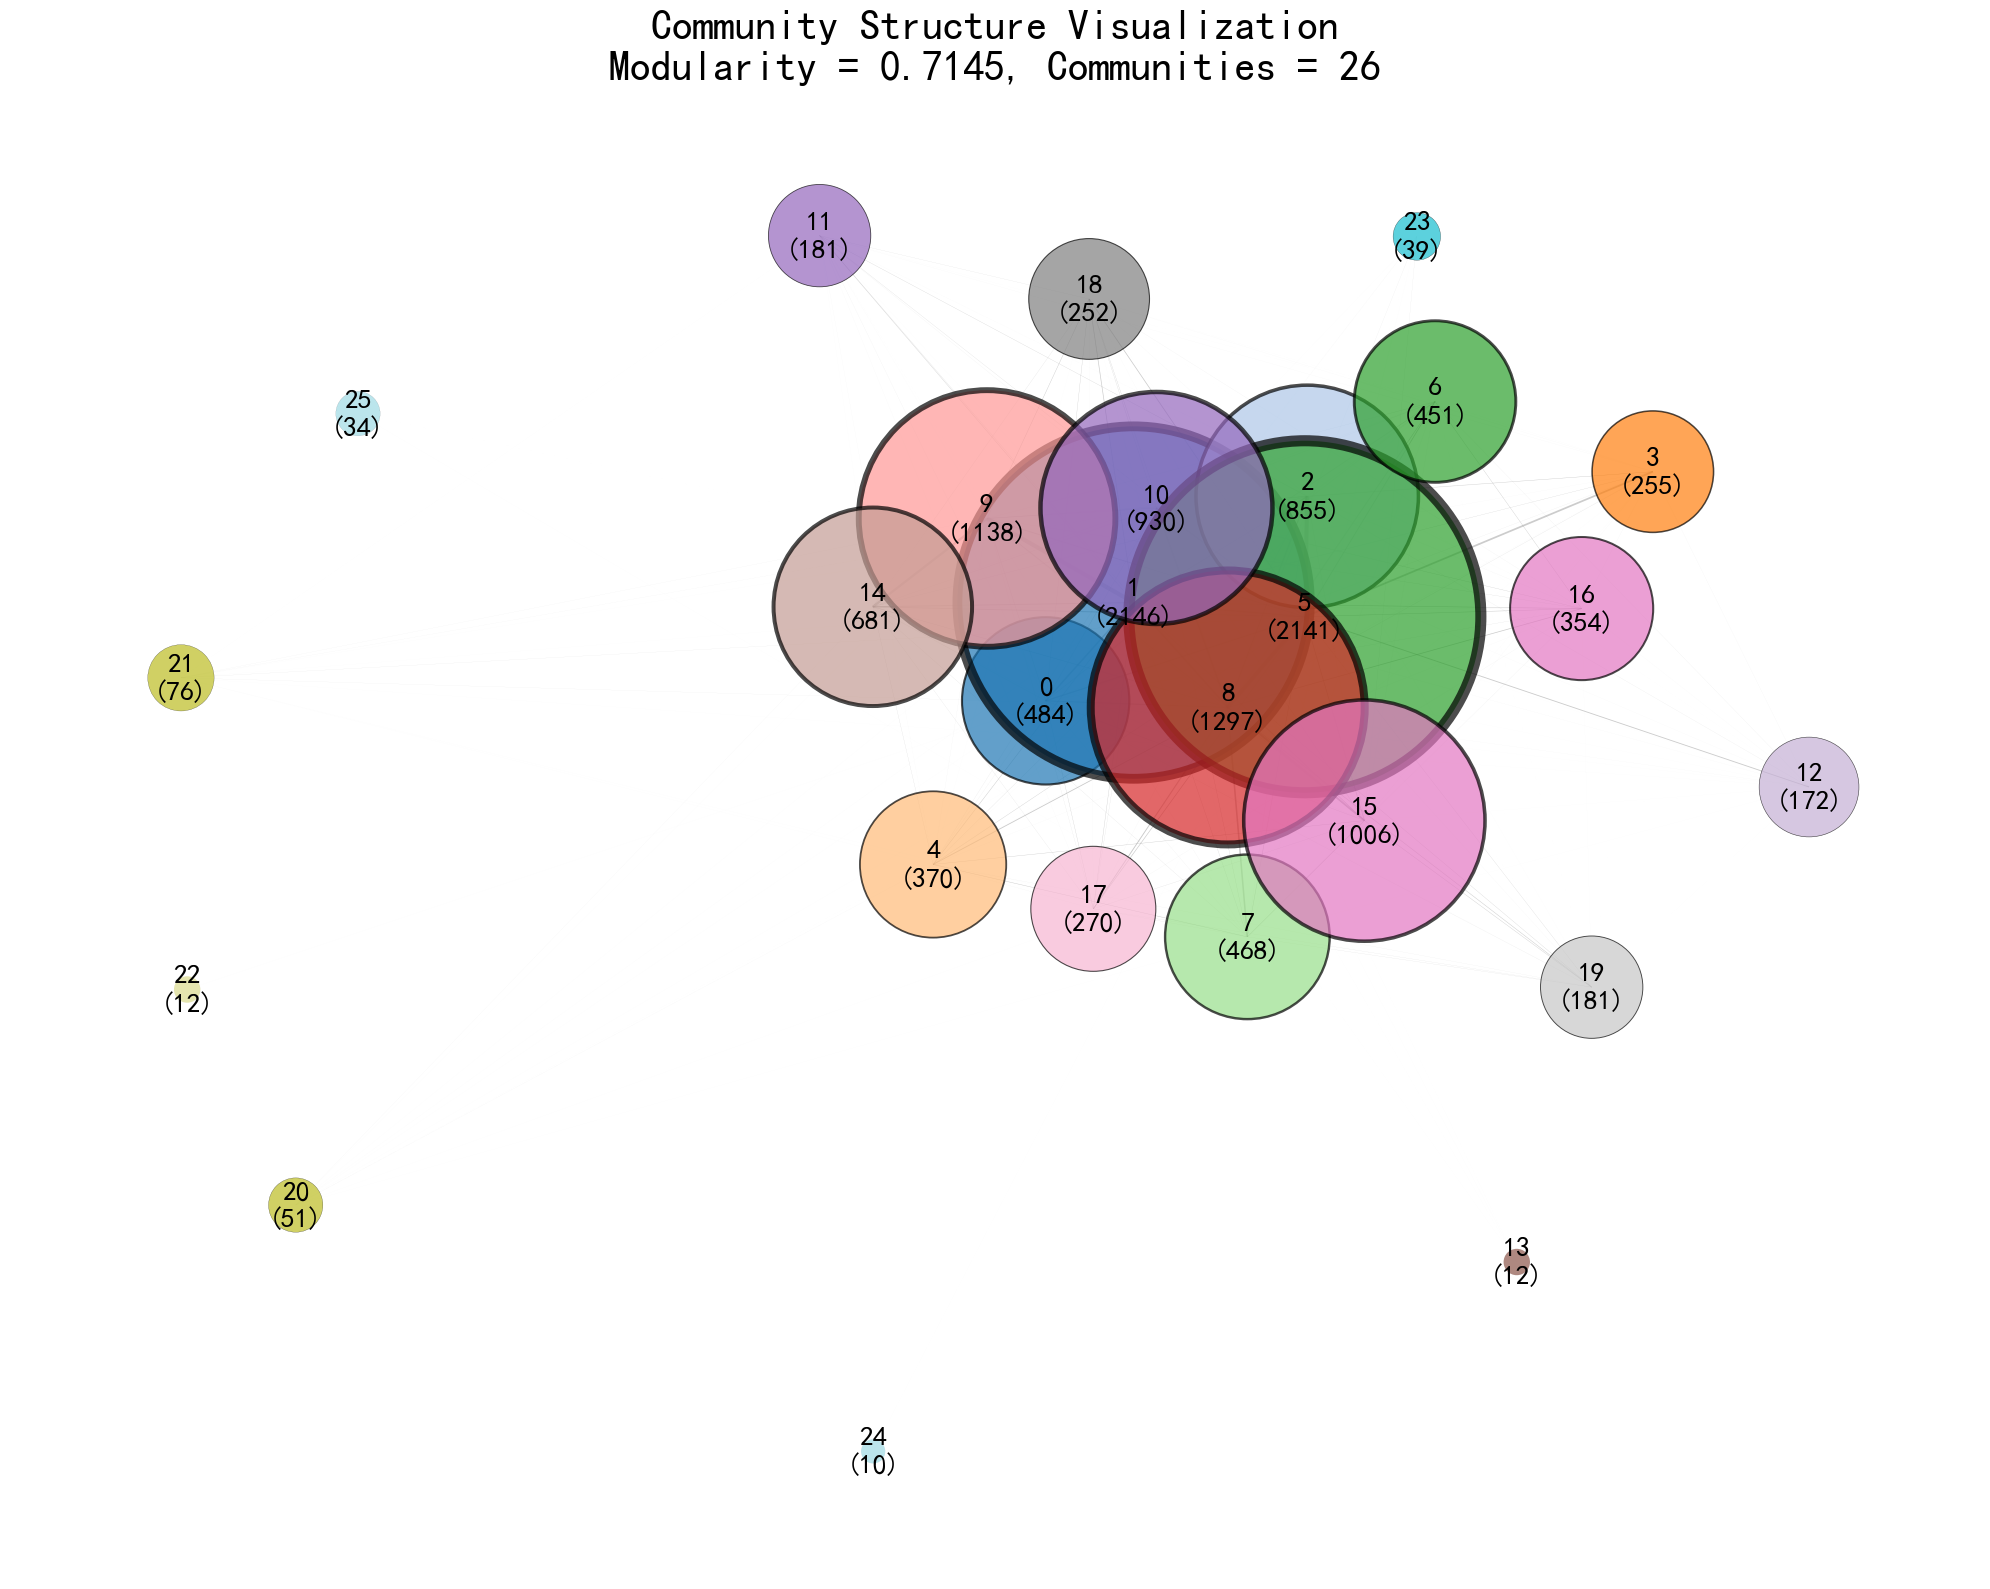


Top 5 communities by internal edges:
Community 5: 11250 internal edges, 2141 nodes
Community 1: 9912 internal edges, 2146 nodes
Community 8: 8088 internal edges, 1297 nodes
Community 9: 5969 internal edges, 1138 nodes
Community 10: 4543 internal edges, 930 nodes


In [60]:
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

partition = community_louvain.best_partition(G_large)

num_communities = len(set(partition.values()))
print(f"\nLouvain Community Detection Results:")
print(f"Number of communities found: {num_communities}")

community_sizes = {}
for node, comm_id in partition.items():
    community_sizes[comm_id] = community_sizes.get(comm_id, 0) + 1

sorted_communities = sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)

print("\nTop 10 largest communities:")
for i, (comm_id, size) in enumerate(sorted_communities[:10], 1):
    print(f"Community {comm_id}: {size} nodes")

modularity = community_louvain.modularity(partition, G_large)
print(f"Modularity: {modularity:.4f}")

internal_edges = {}
for comm_id in set(partition.values()):
    internal_edges[comm_id] = 0

for u, v in G_large.edges():
    if partition[u] == partition[v]:
        internal_edges[partition[u]] += 1

G_community = nx.Graph()

for comm_id in set(partition.values()):
    G_community.add_node(comm_id)

inter_community_edges = {}
for u, v in G_large.edges():
    comm_u = partition[u]
    comm_v = partition[v]
    if comm_u != comm_v:
        edge = tuple(sorted([comm_u, comm_v]))
        inter_community_edges[edge] = inter_community_edges.get(edge, 0) + 1

for (comm_u, comm_v), weight in inter_community_edges.items():
    G_community.add_edge(comm_u, comm_v, weight=weight)

print(f"\nCommunity Graph Statistics:")
print(f"Number of community nodes: {G_community.number_of_nodes()}")
print(f"Number of edges between communities: {G_community.number_of_edges()}")

plt.figure(figsize=(20, 16))

# increase k for more spread out layout
pos = nx.spring_layout(G_community, k=10, iterations=100, seed=3042, scale=3)

node_sizes = [community_sizes[comm_id] * 30 for comm_id in G_community.nodes()]

max_internal = max(internal_edges.values()) if internal_edges else 1
linewidths = [8 * internal_edges[comm_id] / max_internal for comm_id in G_community.nodes()]

edge_weights = [G_community[u][v]['weight'] for u, v in G_community.edges()]
max_weight = max(edge_weights) if edge_weights else 1
edge_widths = [3 * w / max_weight for w in edge_weights]

nx.draw_networkx_nodes(G_community, pos, 
                       node_size=node_sizes,
                       node_color=range(len(G_community.nodes())),
                       cmap=plt.cm.tab20,
                       linewidths=linewidths,
                       edgecolors='black',
                       alpha=0.7)

nx.draw_networkx_edges(G_community, pos, 
                       width=edge_widths,
                       alpha=0.4,
                       edge_color='gray')

labels = {comm_id: f"{comm_id}\n({community_sizes[comm_id]})" 
          for comm_id in G_community.nodes()}
nx.draw_networkx_labels(G_community, pos, labels, 
                       font_size=20,
                       font_color='black',
                       font_weight='bold')

plt.title(f'Community Structure Visualization\nModularity = {modularity:.4f}, Communities = {num_communities}', 
          fontsize=30, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('community_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 communities by internal edges:")
sorted_internal = sorted(internal_edges.items(), key=lambda x: x[1], reverse=True)[:5]
for comm_id, num_edges in sorted_internal:
    print(f"Community {comm_id}: {num_edges} internal edges, {community_sizes[comm_id]} nodes")

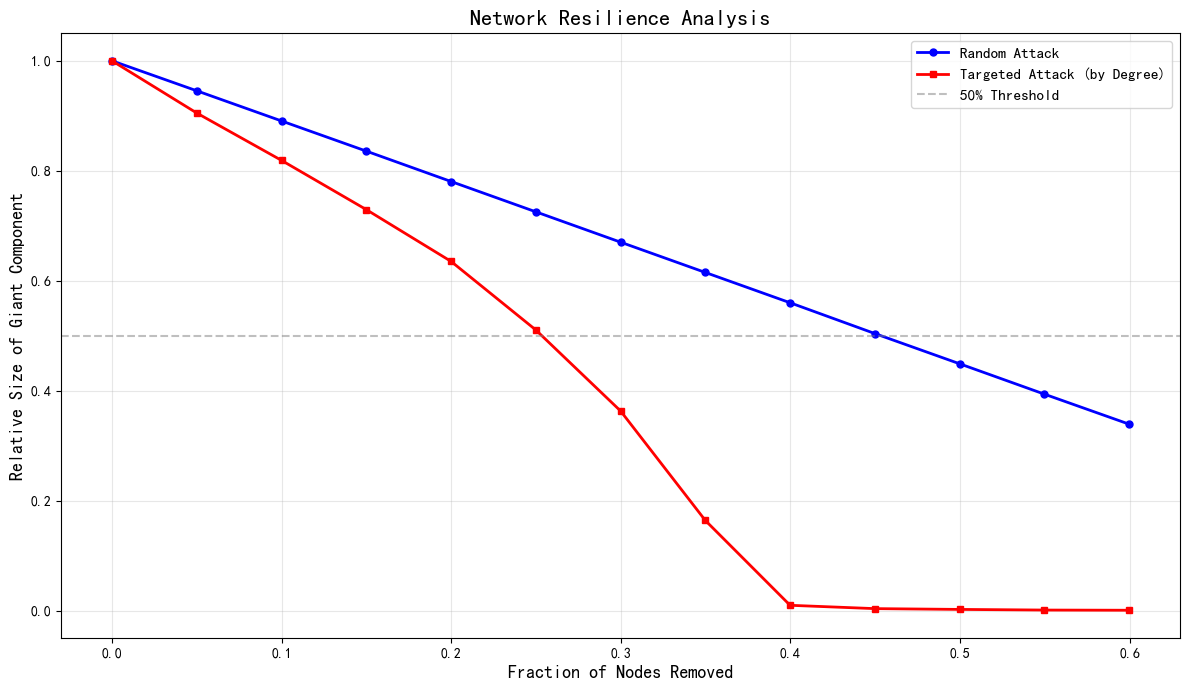

Critical threshold (Random Attack):   50.0%
Critical threshold (Targeted Attack): 30.0%

Network is 1.7x more resilient to random attacks
(i.e., random attacks need to remove 1.7x more nodes to cause same damage)


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def network_resilience(G, attack_type='random', max_removals=0.6, num_trials=5):
    """
    Analyze network resilience under node removal
    
    Parameters:
    - G: networkx graph
    - attack_type: 'random' or 'targeted'
    - max_removals: maximum fraction of nodes to remove
    - num_trials: number of trials for random attack (to get smooth curve)
    
    Returns:
    - fractions: list of removal fractions
    - sizes: list of normalized giant component sizes
    """
    
    initial_gc = max(nx.connected_components(G), key=len)
    initial_size = len(initial_gc)
    total_nodes = G.number_of_nodes()
    step_size = max(1, int(0.05 * total_nodes))
    
    # For random attack, average over multiple trials
    if attack_type == 'random':
        all_trials_sizes = []
        
        for trial in range(num_trials):
            G_temp = G.copy()
            fractions = [0.0]
            sizes = [1.0]
            nodes_remaining = list(G_temp.nodes())
            
            for i in range(step_size, int(max_removals * total_nodes) + 1, step_size):
                # Randomly select nodes to remove
                nodes_to_remove = np.random.choice(nodes_remaining, 
                                                   size=min(step_size, len(nodes_remaining)), 
                                                   replace=False)
                G_temp.remove_nodes_from(nodes_to_remove)
                nodes_remaining = [n for n in nodes_remaining if n not in nodes_to_remove]
                
                # Calculate giant component size
                if G_temp.number_of_nodes() > 0:
                    try:
                        new_gc = max(nx.connected_components(G_temp), key=len)
                        normalized_size = len(new_gc) / initial_size
                    except ValueError:
                        normalized_size = 0
                else:
                    normalized_size = 0
                
                fractions.append(i / total_nodes)
                sizes.append(normalized_size)
            
            all_trials_sizes.append(sizes)
        
        # Average over all trials
        avg_sizes = np.mean(all_trials_sizes, axis=0)
        return fractions, avg_sizes.tolist()
    
    # For targeted attack
    else:
        G_temp = G.copy()
        fractions = [0.0]
        sizes = [1.0]
        
        # Sort nodes by degree (descending)
        sorted_nodes = sorted(G_temp.degree(), key=lambda x: x[1], reverse=True)
        nodes_to_remove = [node for node, degree in sorted_nodes]
        
        for i in range(step_size, int(max_removals * total_nodes) + 1, step_size):
            # Remove highest degree nodes
            nodes_to_remove_step = nodes_to_remove[:min(step_size, len(nodes_to_remove))]
            G_temp.remove_nodes_from(nodes_to_remove_step)
            nodes_to_remove = nodes_to_remove[len(nodes_to_remove_step):]
            
            if G_temp.number_of_nodes() > 0:
                try:
                    new_gc = max(nx.connected_components(G_temp), key=len)
                    normalized_size = len(new_gc) / initial_size
                except ValueError:
                    normalized_size = 0
            else:
                normalized_size = 0
            
            fractions.append(i / total_nodes)
            sizes.append(normalized_size)
        
        return fractions, sizes

np.random.seed(3042)
fractions_random, sizes_random = network_resilience(G_giant, attack_type='random', 
                                                     max_removals=0.6, num_trials=10)
fractions_targeted, sizes_targeted = network_resilience(G_giant, attack_type='targeted', 
                                                         max_removals=0.6)

# Plot
plt.figure(figsize=(12, 7))
plt.plot(fractions_random, sizes_random, 'o-', label='Random Attack', 
         color='blue', linewidth=2, markersize=5)
plt.plot(fractions_targeted, sizes_targeted, 's-', label='Targeted Attack (by Degree)', 
         color='red', linewidth=2, markersize=5)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% Threshold')
plt.title('Network Resilience Analysis', fontsize=16)
plt.xlabel('Fraction of Nodes Removed', fontsize=13)
plt.ylabel('Relative Size of Giant Component', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('network_resilience.png', dpi=300, bbox_inches='tight')
plt.show()

# Find critical thresholds
threshold_random = next((f for f, s in zip(fractions_random, sizes_random) if s < 0.5), None)
threshold_targeted = next((f for f, s in zip(fractions_targeted, sizes_targeted) if s < 0.5), None)


if threshold_random:
    print(f"Critical threshold (Random Attack):   {threshold_random:.1%}")
else:
    print(f"Critical threshold (Random Attack):   Not reached (>60%)")

if threshold_targeted:
    print(f"Critical threshold (Targeted Attack): {threshold_targeted:.1%}")
else:
    print(f"Critical threshold (Targeted Attack): Not reached (>60%)")

if threshold_random and threshold_targeted:
    ratio = threshold_random / threshold_targeted
    print(f"\nNetwork is {ratio:.1f}x more resilient to random attacks")
    print("(i.e., random attacks need to remove {:.1f}x more nodes to cause same damage)".format(ratio))
